# Assignment 4: Custom Data Visualization

## Overview
This assignment requires finding at least two related datasets, combining them, and creating a meaningful visualization that answers a research question. The example here analyzes **US Olympic Medal Performance** relative to total global medals across all Summer Olympic Games.

## Research Question
**How has the United States' share of Olympic medals changed over time?** Is the US becoming more or less dominant in the modern Olympics?

## Learning Objectives
- Find, load, and clean real-world datasets from external sources
- Apply Cairo's principles: Truthfulness, Functionality, Beauty, Insightfulness
- Create publication-quality matplotlib figures with proper labels, legends, and formatting
- Compute derived metrics (percentage/share) from raw data

## Dataset
- **File**: `Country_Medals.csv` — Olympic medal counts by country and year
- **Columns**: Year, Country_Code, Country_Name, Host_city, Host_country, Gold, Silver, Bronze
- **Source**: Wikipedia / publicly available Olympic records

## Visualization
The final chart shows:
- **Blue line**: USA's percentage of total medals (all types) at each Summer Olympics
- **Red line**: USA's percentage of gold medals specifically
- X-axis spans from 1896 (Athens) to 2016 (Rio); gap years mark boycotted Games
- The chart reveals how US dominance has evolved and where dips occurred (boycotted years, boycott retaliation)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Country_Medals.csv', delimiter = ';')
df.head()

,Year,Country_Code,Country_Name,Host_city,Host_country,Gold,Silver,Bronze
0,1932,(USA),United States,Los Angeles,United States,41,32,30
1,1932,(ITA),Italy,Los Angeles,United States,12,12,12
2,1932,(FRA),France,Los Angeles,United States,10,5,4
3,1932,(SWE),Sweden,Los Angeles,United States,9,5,9
4,1932,(JPN),Japan,Los Angeles,United States,7,7,4


### What This Code Does
- Loads `Country_Medals.csv` (semicolon-delimited) into a pandas DataFrame
- Each row represents one country's medal tally at one Olympics year
- Previews the first few rows to verify column names and data types

### What This Code Does
- Computes a `Total_Medals` column (Gold + Silver + Bronze) for every country-year row
- Filters rows to keep only USA (`Country_Code == '(USA)'`) and sorts by year
- Sets `Year` as the DataFrame index so it aligns cleanly with the all-countries aggregate later

In [2]:
df.head()
#df.shape
df['Total_Medals'] =df['Gold'] + df['Silver'] + df['Bronze']
df_USA  = df[df['Country_Code']=='(USA)'].sort_values(by = 'Year', ascending = True)
print(df_USA.shape)
df_USA.set_index(keys = 'Year', inplace = True)
df_USA.head()


(27, 9)


,Country_Code,Country_Name,Host_city,Host_country,Gold,Silver,Bronze,Total_Medals
Year,,,,,,,,
1896,(USA),United States,Athens,Greece,11,7,2,20
1900,(USA),United States,Paris,France,19,14,15,48
1904,(USA),United States,St. Louis,United States,76,78,77,231
1908,(USA),United States,London,Great Britain,23,12,12,47
1912,(USA),United States,Stockholm,Sweden,26,19,19,64


### What This Code Does
- Groups the full dataset by `Year` and sums all medal counts to get the **worldwide total medals per Olympics**
- Result: a 29-row DataFrame (one per Olympics year) with columns Gold, Silver, Bronze, Total_Medals
- This becomes the denominator for computing US market share

In [3]:
df_All_countries = df.groupby(by = ['Year'] ,axis = 0 ) .sum()
df_All_countries = df_All_countries.sort_values(by = 'Year')
print(df_All_countries.shape)
df_All_countries.head()          

(29, 8)


C:\Users\singl\AppData\Local\Temp\ipykernel_102316\14731363.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df_All_countries = df.groupby(by = ['Year'] ,axis = 0 ) .sum()


,Country_Code,Country_Name,Host_city,Host_country,Gold,Silver,Bronze,Total_Medals
Year,,,,,,,,
1896,(USA)(GRE)(GER)(FRA)(GBR)(HUN)(AUT)(AUS)(DEN)(...,United StatesGreeceGermanyFranceGreat BritainH...,AthensAthensAthensAthensAthensAthensAthensAthe...,GreeceGreeceGreeceGreeceGreeceGreeceGreeceGree...,43,43,36,122
1900,(FRA)(USA)(GBR)(ZZX)(BEL)(SUI)(GER)(ITA)(AUS)(...,FranceUnited StatesGreat BritainMixed teamBelg...,ParisParisParisParisParisParisParisParisParisP...,FranceFranceFranceFranceFranceFranceFranceFran...,96,95,93,284
1904,(USA)(GER)(CAN)(CUB)(HUN)(ZZX)(NOR)(AUT)(GBR)(...,United StatesGermanyCanadaCubaHungaryMixed tea...,St. LouisSt. LouisSt. LouisSt. LouisSt. LouisS...,United StatesUnited StatesUnited StatesUnited ...,97,92,91,280
1908,(GBR)(USA)(SWE)(FRA)(GER)(HUN)(CAN)(NOR)(ITA)(...,Great BritainUnited StatesSwedenFranceGermanyH...,LondonLondonLondonLondonLondonLondonLondonLond...,Great BritainGreat BritainGreat BritainGreat B...,110,107,107,324
1912,(USA)(SWE)(GBR)(FIN)(FRA)(GER)(ITA)(RSA)(NOR)(...,United StatesSwedenGreat BritainFinlandFranceG...,StockholmStockholmStockholmStockholmStockholmS...,SwedenSwedenSwedenSwedenSwedenSwedenSwedenSwed...,108,105,104,317


### What This Code Does
- Imports matplotlib and enables inline rendering so figures appear directly in the notebook output

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

### What This Code Does
- Computes two derived series:
  - `percentage_total` = USA Total Medals / World Total Medals per year (element-wise division)
  - `percentage_gold` = USA Gold Medals / World Gold Medals per year
- Plots both as line charts on a single 15×8 figure:
  - **Blue line** (`'b-'`): US share of all medals
  - **Red line** (`'r-'`): US share of gold medals only
- Sets x-axis ticks every 4 years from 1896 to 2016 (rotated 45° for readability)
- Adds title, axis labels, and legend to make the chart self-explanatory

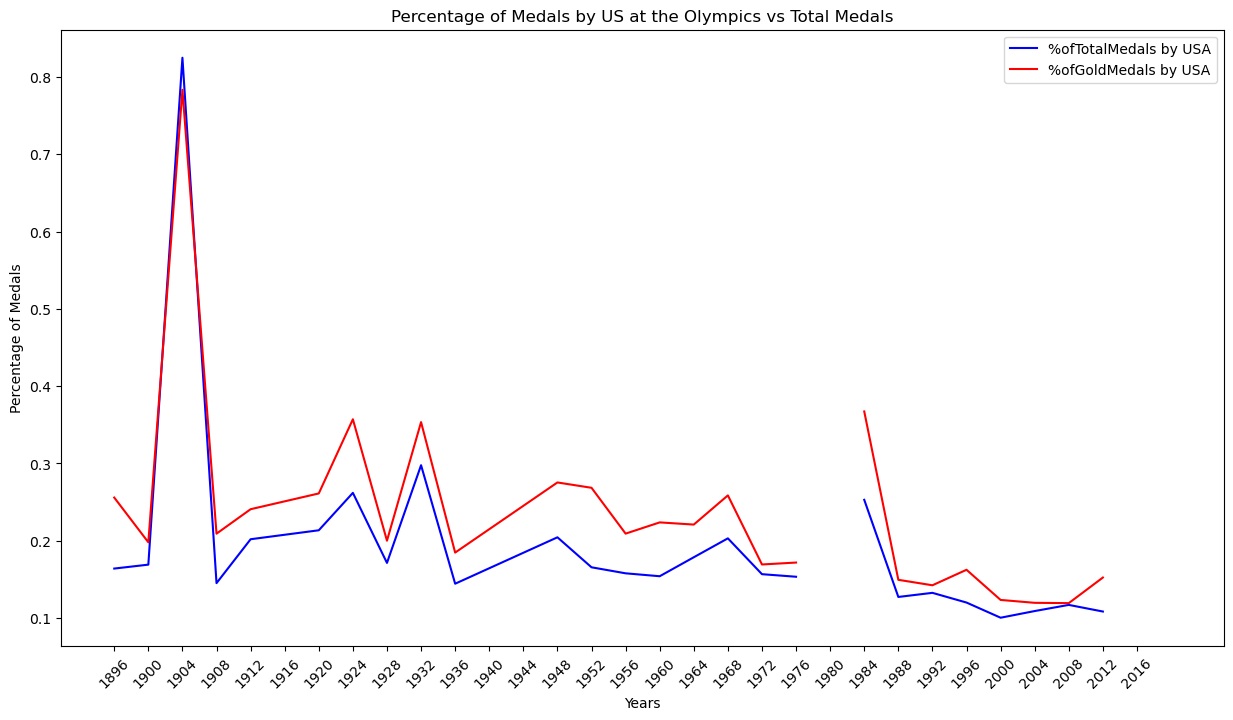

In [5]:
#df_All_countries['Total_Medals'].values
df_All_countries.index.values

#plt.plot( df_All_countries.index.values, df_All_countries['Total_Medals'].values,   'b-o', label = 'Total Medals by All Countries')
#plt.plot( df_USA.index.values, df_USA['Total_Medals'].values,   'g-o', label = 'Total Medals by USA')

#plt.plot( df_All_countries.index.values, df_All_countries['Gold'].values,   'gx', label = 'Gold Medals by All Countries')
#plt.plot( df_USA.index.values, df_USA['Gold'].values,   'y-', label = 'Gold Medals by USA')
#plt.twinx()
percentage_total = (df_USA['Total_Medals']/ df_All_countries['Total_Medals']).values
percentage_gold = (df_USA['Gold']/ df_All_countries['Gold']).values

plt.figure(num =1 , figsize = (15,8))
plt.plot(df_All_countries.index.values, percentage_total, 'b-', label = '%ofTotalMedals by USA')
plt.plot(df_All_countries.index.values, percentage_gold, 'r-', label = '%ofGoldMedals by USA')
#plt.plot( df_All_countries.index.values, ,   'gx', label = 'Gold Medals by All Countries')

plt.title("Percentage of Medals by US at the Olympics vs Total Medals")
plt.xlabel("Years")
plt.ylabel("Percentage of Medals")
plt.xticks(np.arange(1896, 2020, 4), rotation =45 ) 

#plt.ylabel('Percentage of Medals Won')
#plt.xlabel('Year')
plt.legend()
plt.show()
